In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow_decision_forests as tfdf
import pandas as pd

https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/RandomForestModel

In [2]:
dataset_df = pd.read_csv("./data/final_rolling.csv")

In [3]:
training = dataset_df[dataset_df["raceId"] < 2022]
test = dataset_df[dataset_df["year"] >= 2022]
single = dataset_df[dataset_df["raceId"] == 1134]

In [4]:
predictors = ["raceId", "grid", "position", "pos_delta", "driver_code", "constructor_code", "circuit_code", "grid_rolling", "position_rolling", "pos_delta_rolling"]

In [5]:
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(training[predictors], label="driver_code")
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test[predictors])
single_ds = tfdf.keras.pd_dataframe_to_tf_dataset(single[predictors])

In [6]:
model = tfdf.keras.RandomForestModel(verbose=0)

model.fit(train_ds)

[INFO 24-08-02 14:58:44.9484 CEST kernel.cc:1233] Loading model from path /var/folders/hk/ffpx1y0s2cn133v15g3yks080000gn/T/tmpzmja8slj/model/ with prefix 02307fa3e30f444a
[INFO 24-08-02 14:58:45.2528 CEST decision_forest.cc:734] Model loaded with 300 root(s), 225456 node(s), and 9 input feature(s).
[INFO 24-08-02 14:58:45.2529 CEST abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 24-08-02 14:58:45.2529 CEST kernel.cc:1061] Use fast generic engine


In [7]:
predictions = model.predict(test_ds)

2/2 [==============================] - 0s 11ms/step


### Prediction tables:
    Rows - prediction number
    Column - driverId

In [8]:
predictions

array([[0.        , 0.        , 0.00333333, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.01      , 0.01      , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.7366661 ],
       [0.        , 0.01333333, 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [9]:
predictions_df = pd.DataFrame(predictions)

In [10]:
predictions_df.transpose()

,0,1,2,3,4,5,6,7,8,9,...,1149,1150,1151,1152,1153,1154,1155,1156,1157,1158
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.013333,0.006667,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.949999,0.003333,0.000000,0.003333,0.003333,0.020000,0.010000,0.000000,0.013333
2,0.003333,0.000000,0.000000,0.003333,0.016667,0.080000,0.283333,0.050000,0.693333,0.010000,...,0.106667,0.003333,0.016667,0.000000,0.000000,0.003333,0.000000,0.010000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.046667,0.030000,0.000000,0.536666,0.020000,0.020000,0.000000,0.080000,...,0.000000,0.003333,0.000000,0.003333,0.793333,0.063333,0.040000,0.003333,0.123333,0.026667
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.003333,0.000000,0.000000,0.000000,0.010000,0.000000,0.003333,...,0.000000,0.000000,0.006667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.006667,0.000000,0.000000,0.000000,0.000000
8,0.006667,0.000000,0.000000,0.003333,0.006667,0.156667,0.013333,0.170000,0.066667,0.033333,...,0.020000,0.000000,0.756666,0.003333,0.000000,0.000000,0.000000,0.003333,0.006667,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.006667,0.000000,0.006667,0.000000,0.033333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [11]:
with_names = pd.merge(test, predictions_df, left_on="driver_code", right_on=predictions_df.index)

with_names[["raceId", "driverRef", "position", 0]]

,raceId,driverRef,position,0
0,1074,leclerc,1.0,0.0
1,1074,sainz,2.0,0.0
2,1074,hamilton,3.0,0.0
3,1074,russell,4.0,0.0
4,1074,kevin_magnussen,5.0,0.0
...,...,...,...,...
1154,1134,tsunoda,16.0,0.0
1155,1134,sargeant,17.0,0.0
1156,1134,hulkenberg,18.0,0.0
1157,1134,zhou,19.0,0.0


In [12]:
model.make_inspector().evaluation()

Evaluation(num_examples=2779, accuracy=0.6308024469233537, loss=0.8841431200646398, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

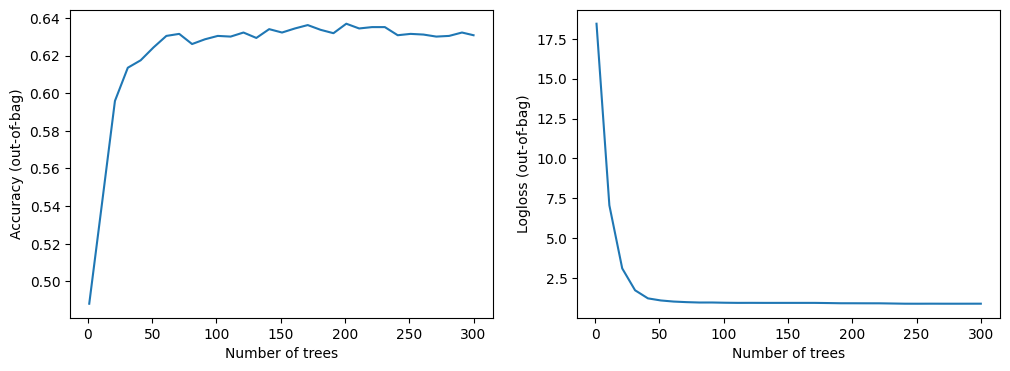

In [13]:
import matplotlib.pyplot as plt

logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")

plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")

plt.show()


In [14]:
# import dtreeviz

In [15]:
model.make_inspector().features()

["circuit_code" (1; #1),
 "constructor_code" (1; #2),
 "grid" (1; #3),
 "grid_rolling" (1; #4),
 "pos_delta" (1; #5),
 "pos_delta_rolling" (1; #6),
 "position" (1; #7),
 "position_rolling" (1; #8),
 "raceId" (1; #9)]